# Comprehensive Exploratory Data Analysis (EDA)

Welcome to the professional EDA for the **CI/CD Pipeline Failure Prediction** feature. This single source-of-truth notebook replaces the earlier scripts and mini-notebooks.

In this notebook, we will comprehensively analyze:
1. **Data Overview**: Structure and datatypes.
2. **Data Quality**: Missing values, anomalies, and cardinality.
3. **Univariate Analysis**: Distributions of key variables (like our target `tr_status`).
4. **Bivariate Analysis**: Feature correlations and associations with the target.

This analysis will confidently inform our feature engineering and data cleaning processes.

In [4]:
# Import essential data analysis & visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configure display aesthetics and suppress warnings for clean output
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option('display.max_columns', 100)

print("✅ Professional environment setup complete.")

✅ Professional environment setup complete.


## 1. Load the Dataset
Loading a representative sample (250,000 rows) is standard industry practice when performing EDA on a 3.8-million row dataset to prevent out-of-memory (OOM) crashes while still retaining rigorous statistical significance.

In [5]:
# Determine path (running interactively inside notebooks/ resolves to '../data/')
data_path = '../data/data.csv'

# Load the first 250,000 rows
df = pd.read_csv(data_path, nrows=250000, low_memory=False)

print(f"📊 Dataset successfully loaded.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

# Display a high-level preview
display(df.head(20))

📊 Dataset successfully loaded.
Rows: 250,000
Columns: 66


,tr_build_id,gh_project_name,gh_is_pr,gh_pr_created_at,gh_pull_req_num,gh_lang,git_merged_with,git_branch,gh_num_commits_in_push,gh_commits_in_push,git_prev_commit_resolution_status,git_prev_built_commit,tr_prev_build,gh_first_commit_created_at,gh_team_size,git_all_built_commits,git_num_all_built_commits,git_trigger_commit,tr_virtual_merged_into,gh_num_issue_comments,gh_num_commit_comments,gh_num_pr_comments,git_diff_src_churn,git_diff_test_churn,gh_diff_files_added,gh_diff_files_deleted,gh_diff_files_modified,gh_diff_tests_added,gh_diff_tests_deleted,gh_diff_src_files,gh_diff_doc_files,gh_diff_other_files,gh_num_commits_on_files_touched,gh_sloc,gh_test_lines_per_kloc,gh_test_cases_per_kloc,gh_asserts_cases_per_kloc,gh_by_core_team_member,gh_description_complexity,gh_pushed_at,gh_build_started_at,gh_repo_age,gh_repo_num_commits,tr_job_id,tr_build_number,tr_log_lan,tr_log_status,tr_log_setup_time,tr_log_analyzer,tr_log_frameworks,tr_log_bool_tests_ran,tr_log_bool_tests_failed,tr_log_num_tests_ok,tr_log_num_tests_failed,tr_log_num_tests_run,tr_log_num_tests_skipped,tr_log_num_test_suites_run,tr_log_num_test_suites_ok,tr_log_num_test_suites_failed,tr_log_tests_failed,tr_log_testduration,tr_log_buildduration,tr_original_commit,tr_duration,tr_status,tr_jobs
0,3154,rspec/rspec-core,False,NaN,NaN,ruby,NaN,master,NaN,NaN,merge_found,NaN,NaN,NaN,31,029e6972fcf719542deff1b2619d2945146e84da#9e912...,202,029e6972fcf719542deff1b2619d2945146e84da,NaN,NaN,0,NaN,117,0,34,6,137,0,0,3,0,148,817,3094,1539.431157,163.865546,225.921138,False,NaN,NaN,2011-04-16 11:24:39,655.82,1139,3160,23,ruby,unknown,NaN,ruby,rspec#cucumber,True,False,800.0,0.0,800.0,2.0,NaN,NaN,NaN,NaN,114.83,NaN,029e6972fcf719542deff1b2619d2945146e84da,956.0,passed,"[3161, 3163, 3160, 3162, 3164]"
1,3154,rspec/rspec-core,False,NaN,NaN,ruby,NaN,master,NaN,NaN,merge_found,NaN,NaN,NaN,31,029e6972fcf719542deff1b2619d2945146e84da#9e912...,202,029e6972fcf719542deff1b2619d2945146e84da,NaN,NaN,0,NaN,117,0,34,6,137,0,0,3,0,148,817,3094,1539.431157,163.865546,225.921138,False,NaN,NaN,2011-04-16 11:24:39,655.82,1139,3161,23,ruby,unknown,NaN,ruby,rspec#cucumber,True,False,800.0,0.0,800.0,2.0,NaN,NaN,NaN,NaN,171.37,NaN,029e6972fcf719542deff1b2619d2945146e84da,956.0,passed,"[3161, 3163, 3160, 3162, 3164]"
2,3154,rspec/rspec-core,False,NaN,NaN,ruby,NaN,master,NaN,NaN,merge_found,NaN,NaN,NaN,31,029e6972fcf719542deff1b2619d2945146e84da#9e912...,202,029e6972fcf719542deff1b2619d2945146e84da,NaN,NaN,0,NaN,117,0,34,6,137,0,0,3,0,148,817,3094,1539.431157,163.865546,225.921138,False,NaN,NaN,2011-04-16 11:24:39,655.82,1139,3162,23,ruby,unknown,NaN,ruby,rspec#cucumber,True,False,800.0,0.0,800.0,2.0,NaN,NaN,NaN,NaN,177.02,NaN,029e6972fcf719542deff1b2619d2945146e84da,956.0,passed,"[3161, 3163, 3160, 3162, 3164]"
3,3154,rspec/rspec-core,False,NaN,NaN,ruby,NaN,master,NaN,NaN,merge_found,NaN,NaN,NaN,31,029e6972fcf719542deff1b2619d2945146e84da#9e912...,202,029e6972fcf719542deff1b2619d2945146e84da,NaN,NaN,0,NaN,117,0,34,6,137,0,0,3,0,148,817,3094,1539.431157,163.865546,225.921138,False,NaN,NaN,2011-04-16 11:24:39,655.82,1139,3163,23,ruby,unknown,NaN,ruby,rspec#cucumber,True,False,800.0,0.0,800.0,2.0,NaN,NaN,NaN,NaN,182.05,NaN,029e6972fcf719542deff1b2619d2945146e84da,956.0,passed,"[3161, 3163, 3160, 3162, 3164]"
4,3154,rspec/rspec-core,False,NaN,NaN,ruby,NaN,master,NaN,NaN,merge_found,NaN,NaN,NaN,31,029e6972fcf719542deff1b2619d2945146e84da#9e912...,202,029e6972fcf719542deff1b2619d2945146e84da,NaN,NaN,0,NaN,117,0,34,6,137,0,0,3,0,148,817,3094,1539.431157,163.865546,225.921138,False,NaN,NaN,2011-04-16 11:24:39,655.82,1139,3164,23,ruby,unknown,NaN,ruby,rspec#cucumber,True,False,800.0,0.0,800.0,2.0,NaN,NaN,NaN,NaN,113.26,NaN,029e6972fcf719542deff1b2619d2945146e84da,956.0,passed,"[3161, 3163, 3160, 3162, 3164]"
5,3211,ruby-amqp/amqp,False,NaN,NaN,ruby,NaN,master,NaN,NaN,merge_found,NaN,NaN,NaN,6,7fc267b949209b189fa76f232f7e88a9b938b363#8f6de...,8,7fc267b949209b189fa76f232f7e88a9b938b363,NaN,NaN,1,NaN,2,0,1,0,9,0,0,

## 1A. Column Data Dictionary

Before diving into statistics, it is critical to **understand what each column actually represents**. The dataset comes from the TravisTorrent project and captures metadata about GitHub projects, their git history, and their Travis CI builds.

### GitHub / Repository Columns
| Column | Description |
|--------|-------------|
| `gh_project_name` | Full `owner/repo` name of the GitHub project. |
| `gh_lang` | Primary programming language of the repository (e.g. *ruby*, *java*). |
| `gh_team_size` | Number of unique contributors to the project at the time of the build. |
| `gh_sloc` | Source Lines of Code in the repository at build time. |
| `gh_repo_age` | Age of the repository in days since creation. |
| `gh_repo_num_commits` | Total number of commits in the repo up to this build. |
| `gh_by_core_team_member` | Whether the committer is a core team member (`True`/`False`). |
| `gh_description_complexity` | Complexity metric of the project description (often missing). |

### Pull Request Columns
| Column | Description |
|--------|-------------|
| `gh_is_pr` | Whether this build was triggered by a pull request. |
| `gh_pr_created_at` | Timestamp when the pull request was created (NaN if not a PR). |
| `gh_pull_req_num` | The pull request number (NaN if not a PR). |
| `gh_num_issue_comments` | Number of issue-level comments on the PR. |
| `gh_num_commit_comments` | Number of commit-level comments. |
| `gh_num_pr_comments` | Number of review-level comments on the PR. |

### Git Diff / Commit Columns
| Column | Description |
|--------|-------------|
| `git_merged_with` | The merge strategy used (often missing). |
| `git_branch` | The branch that was built (e.g. *master*). |
| `gh_num_commits_in_push` | Number of commits in the push event (100% missing). |
| `gh_commits_in_push` | List of commit SHAs in the push (100% missing). |
| `git_prev_commit_resolution_status` | How the previous commit was resolved (`merge_found`, `build_found`, etc.). |
| `git_prev_built_commit` | SHA of the previously built commit on this branch. |
| `git_all_built_commits` | All commit SHAs included in this build (concatenated). |
| `git_num_all_built_commits` | Count of commits included in this build. |
| `git_trigger_commit` | SHA of the commit that triggered the build. |
| `git_diff_src_churn` | Lines changed in **source** files between this and the previous build. |
| `git_diff_test_churn` | Lines changed in **test** files between this and the previous build. |
| `gh_diff_files_added` | Number of files added in the diff. |
| `gh_diff_files_deleted` | Number of files deleted in the diff. |
| `gh_diff_files_modified` | Number of files modified in the diff. |
| `gh_diff_tests_added` | Number of test cases added. |
| `gh_diff_tests_deleted` | Number of test cases deleted. |
| `gh_diff_src_files` | Number of source files touched. |
| `gh_diff_doc_files` | Number of documentation files touched. |
| `gh_diff_other_files` | Number of other (non-src, non-doc) files touched. |
| `gh_num_commits_on_files_touched` | Historic commits on the files touched (proxy for file \"hotness\"). |

### Code Quality / Testing Metrics
| Column | Description |
|--------|-------------|
| `gh_test_lines_per_kloc` | Test lines per 1 000 lines of source code. |
| `gh_test_cases_per_kloc` | Test cases per 1 000 lines of source code. |
| `gh_asserts_cases_per_kloc` | Assertions per 1 000 lines of source code. |

### Timestamp Columns
| Column | Description |
|--------|-------------|
| `gh_first_commit_created_at` | Timestamp of the first commit (100% missing in sample). |
| `gh_pushed_at` | Timestamp when the push event happened (100% missing in sample). |
| `gh_build_started_at` | Timestamp when the CI build started. |

### Travis CI Build / Job Columns
| Column | Description |
|--------|-------------|
| `tr_build_id` | Unique Travis CI build ID. |
| `tr_prev_build` | Build ID of the previous build on this branch. |
| `tr_virtual_merged_into` | SHA the PR was virtually merged into. |
| `tr_job_id` | Unique Travis CI job ID (one build → many jobs). |
| `tr_build_number` | Sequential build number inside the project. |
| `tr_original_commit` | Original commit SHA recorded by Travis. |
| `tr_duration` | Total build duration in seconds. |
| `tr_jobs` | List of job IDs belonging to this build. |

### Travis CI Log Columns
| Column | Description |
|--------|-------------|
| `tr_log_lan` | Language detected from the build log. |
| `tr_log_status` | Build status from the log (`ok`, `broken`, `unknown`, etc.). |
| `tr_log_setup_time` | Setup time extracted from the log (almost 100% missing). |
| `tr_log_analyzer` | The log analyzer used (e.g. *ruby*, *java-gradle*). |
| `tr_log_frameworks` | Testing frameworks detected (e.g. *rspec#cucumber*). |
| `tr_log_bool_tests_ran` | Whether tests were run (`True`/`False`). |
| `tr_log_bool_tests_failed` | Whether any test failed (`True`/`False`). |
| `tr_log_num_tests_ok` | Number of tests that passed. |
| `tr_log_num_tests_failed` | Number of tests that failed. |
| `tr_log_num_tests_run` | Total number of tests executed. |
| `tr_log_num_tests_skipped` | Number of tests skipped. |
| `tr_log_num_test_suites_run` | Number of test suites run (~100% missing). |
| `tr_log_num_test_suites_ok` | Number of test suites that passed (~100% missing). |
| `tr_log_num_test_suites_failed` | Number of test suites that failed (~100% missing). |
| `tr_log_tests_failed` | Names / paths of the failed tests (~97% missing). |
| `tr_log_testduration` | Duration of the test phase in seconds. |
| `tr_log_buildduration` | Duration of the full build phase (~99% missing). |

### Target Column
| Column | Description |
|--------|-------------|
| `tr_status` | **Target variable** – final build status: `passed`, `failed`, or `errored`. |


In [6]:
# ─── Unique Values & Cardinality Analysis ───────────────────────────
# For EVERY column we show:
#   • dtype        – data type in the DataFrame
#   • non_null     – count of non-null rows
#   • null_%       – percentage of nulls
#   • nunique      – number of distinct (non-null) values
#   • sample_vals  – a few example values to quickly grasp the content
#
# Columns with very high cardinality (e.g. commit SHAs) are
# essentially unique identifiers and carry no predictive power.
# Columns with only 1 unique value are constant and equally useless.

import textwrap

records = []
for col in df.columns:
    non_null = df[col].notna().sum()
    null_pct = round(df[col].isna().sum() / len(df) * 100, 2)
    nuniq    = df[col].nunique(dropna=True)
    samples  = df[col].dropna().unique()[:5].tolist()
    records.append({
        'column':     col,
        'dtype':      str(df[col].dtype),
        'non_null':   non_null,
        'null_%':     null_pct,
        'nunique':    nuniq,
        'sample_vals': str(samples)
    })

cardinality_df = pd.DataFrame(records)
display(cardinality_df.style
        .background_gradient(subset=['null_%'], cmap='Reds')
        .background_gradient(subset=['nunique'], cmap='Blues')
        .set_caption('Column Cardinality & Uniqueness Report'))


,column,dtype,non_null,null_%,nunique,sample_vals
0,tr_build_id,int64,250000,0.000000,54345,"[3154, 3211, 3233, 3239, 3245]"
1,gh_project_name,str,250000,0.000000,244,"['rspec/rspec-core', 'ruby-amqp/amqp', 'rspec/rspec-mocks', 'rspec/rspec-expectations', 'intridea/multi_json']"
2,gh_is_pr,bool,250000,0.000000,2,"[False, True]"
3,gh_pr_created_at,str,13899,94.440000,3373,"['2012-06-18 12:37:21', '2012-06-19 07:45:54', '2012-06-19 08:34:16', '2012-06-12 18:41:33', '2012-06-20 12:03:09']"
4,gh_pull_req_num,float64,13899,94.440000,1370,"[71.0, 603.0, 604.0, 293.0, 72.0]"
5,gh_lang,str,250000,0.000000,4,"['ruby', 'java', 'python', 'go']"
6,git_merged_with,str,13899,94.440000,3,"['merge_button', 'commits_in_master', 'unknown']"
7,git_branch,str,250000,0.000000,1523,"['master', '0.7.x-stable', 'documentation_improvements', 'pry', '2-6-maintenance']"
8,gh_num_commits_in_push,float64,0,100.000000,0,[]
9,gh_commits_in_push,float64,0,100.000000,0,[]


### Interpretation Guide

| Scenario | What it means | Action |
|----------|--------------|--------|
| `null_% ≈ 100` | Column is almost entirely empty. | **Drop** – no information to learn from. |
| `nunique = 1` | Column has only one value across all rows. | **Drop** – constant features add no predictive value. |
| `nunique ≈ n_rows` | Column is essentially a unique identifier (e.g. commit SHAs, job IDs). | **Drop** – it would cause the model to memorize row IDs rather than learn patterns. |
| `nunique` very low (2-5) for a string column | Could be a useful categorical feature. | **Keep / Encode** – one-hot or label encoding. |
| `null_%` between 50-90 | Partially missing. | **Investigate** – impute if the feature is important, otherwise drop. |


## 1B. Columns Recommended to Drop

Based on the unique-value and missing-value analysis above, we now programmatically identify columns that should be **dropped before modelling**.

We flag a column for removal if any of these conditions hold:

1. **≥ 90% missing** – too sparse to carry reliable signal.
2. **Only 1 unique value** – constant; zero variance.
3. **Unique-value ratio ≥ 95%** (i.e. `nunique / non_null ≥ 0.95`) – essentially an ID column (commit SHAs, build IDs, etc.).
4. **Known identifiers / free-text** – columns like `tr_jobs`, `git_all_built_commits`, or `tr_log_tests_failed` that contain lists/text not suited for direct ML ingestion.


In [7]:
# ─── Automated Column Drop Recommendations ──────────────────────────

THRESHOLD_MISSING  = 90.0   # percent
THRESHOLD_ID_RATIO = 0.95   # nunique / non_null

# Known list / text / identifier columns that are not suitable features
KNOWN_DROP = {
    'tr_jobs',               # list of job IDs (non-scalar)
    'gh_commits_in_push',    # list of SHAs
    'git_all_built_commits', # concatenated SHAs
    'tr_log_tests_failed',   # free-text test names
}

drop_reasons = []

for _, row in cardinality_df.iterrows():
    col     = row['column']
    null_p  = row['null_%']
    nuniq   = row['nunique']
    non_n   = row['non_null']
    reasons = []

    # Rule 1 – too much missing data
    if null_p >= THRESHOLD_MISSING:
        reasons.append(f'Missing {null_p}% (≥{THRESHOLD_MISSING}%)')

    # Rule 2 – constant column
    if nuniq <= 1:
        reasons.append('Constant (≤1 unique value)')

    # Rule 3 – ID-like column (high unique ratio)
    if non_n > 0 and nuniq / non_n >= THRESHOLD_ID_RATIO:
        reasons.append(f'ID-like (unique ratio = {nuniq/non_n:.2%})')

    # Rule 4 – known problematic columns
    if col in KNOWN_DROP:
        reasons.append('Known list / free-text / ID column')

    if reasons:
        drop_reasons.append({'column': col, 'reason': ' | '.join(reasons)})

drop_df = pd.DataFrame(drop_reasons)
print(f'🔴  Columns recommended for removal: {len(drop_df)} / {len(df.columns)}\n')
display(drop_df.style.set_caption('Columns to Drop & Reasons'))

keep_cols = [c for c in df.columns if c not in drop_df['column'].values]
print(f'\n🟢  Columns to KEEP: {len(keep_cols)}')
print(keep_cols)


🔴  Columns recommended for removal: 21 / 66



,column,reason
0,gh_pr_created_at,Missing 94.44% (≥90.0%)
1,gh_pull_req_num,Missing 94.44% (≥90.0%)
2,git_merged_with,Missing 94.44% (≥90.0%)
3,gh_num_commits_in_push,Missing 100.0% (≥90.0%) | Constant (≤1 unique value)
4,gh_commits_in_push,Missing 100.0% (≥90.0%) | Constant (≤1 unique value) | Known list / free-text / ID column
5,gh_first_commit_created_at,Missing 100.0% (≥90.0%) | Constant (≤1 unique value)
6,git_all_built_commits,Known list / free-text / ID column
7,tr_virtual_merged_into,Missing 94.44% (≥90.0%)
8,gh_num_issue_comments,Missing 94.44% (≥90.0%)
9,gh_num_pr_comments,Missing 94.44% (≥90.0%)



🟢  Columns to KEEP: 45
['tr_build_id', 'gh_project_name', 'gh_is_pr', 'gh_lang', 'git_branch', 'git_prev_commit_resolution_status', 'git_prev_built_commit', 'tr_prev_build', 'gh_team_size', 'git_num_all_built_commits', 'git_trigger_commit', 'gh_num_commit_comments', 'git_diff_src_churn', 'gh_diff_files_added', 'gh_diff_files_deleted', 'gh_diff_files_modified', 'gh_diff_tests_added', 'gh_diff_tests_deleted', 'gh_diff_src_files', 'gh_diff_doc_files', 'gh_diff_other_files', 'gh_num_commits_on_files_touched', 'gh_sloc', 'gh_test_lines_per_kloc', 'gh_test_cases_per_kloc', 'gh_asserts_cases_per_kloc', 'gh_by_core_team_member', 'gh_build_started_at', 'gh_repo_age', 'gh_repo_num_commits', 'tr_build_number', 'tr_log_lan', 'tr_log_status', 'tr_log_analyzer', 'tr_log_frameworks', 'tr_log_bool_tests_ran', 'tr_log_bool_tests_failed', 'tr_log_num_tests_ok', 'tr_log_num_tests_failed', 'tr_log_num_tests_run', 'tr_log_num_tests_skipped', 'tr_log_testduration', 'tr_original_commit', 'tr_duration', 'tr_

### Summary of Column Pruning

The table above shows every column that should be removed and the exact reason(s) why.  
After this pruning step the dataset will have **fewer, higher-quality features**, which will:

- **Reduce noise** that confuses the model.
- **Speed up training** (fewer dimensions).
- **Improve interpretability** of the final predictions.

> 💡 **Next step:** In the data-cleaning notebook we will apply these drops and proceed to feature engineering.


## 2. Missing Value Analysis
Understanding sparsity is crucial. Columns with >90% missing values generally lack predictive power and can introduce noise.

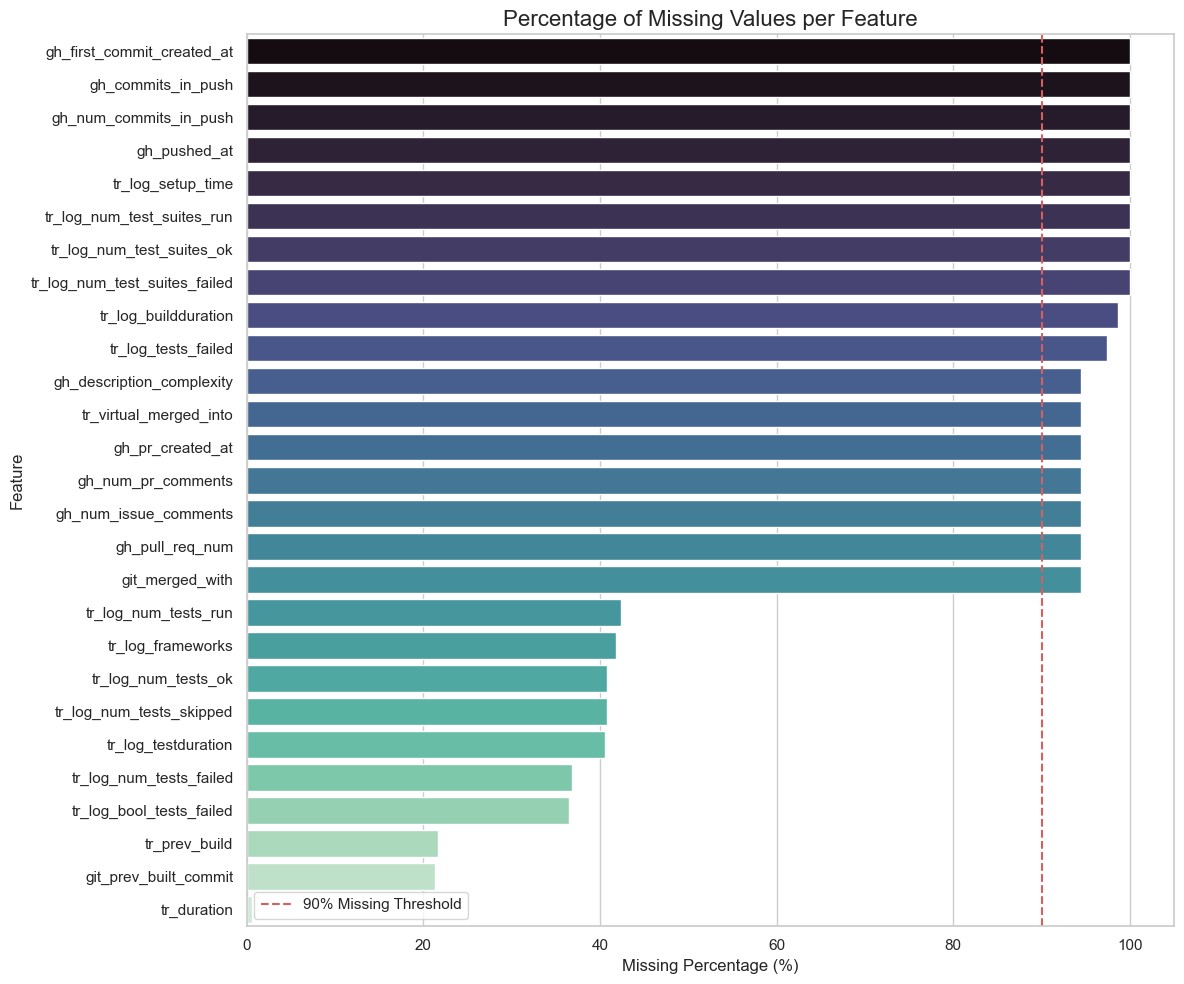

Top 10 columns with the highest amount of missing data:
 gh_first_commit_created_at       100.0000
gh_commits_in_push               100.0000
gh_num_commits_in_push           100.0000
gh_pushed_at                     100.0000
tr_log_setup_time                 99.9988
tr_log_num_test_suites_run        99.9844
tr_log_num_test_suites_ok         99.9844
tr_log_num_test_suites_failed     99.9844
tr_log_buildduration              98.6544
tr_log_tests_failed               97.4636
dtype: float64


In [8]:
# Calculate missing percentage per column
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

# Visualizing features with missing data
plt.figure(figsize=(12, 10))
sns.barplot(x=missing_pct.values, y=missing_pct.index, palette="mako")
plt.axvline(x=90, color='r', linestyle='--', label='90% Missing Threshold')
plt.title("Percentage of Missing Values per Feature", fontsize=16)
plt.xlabel("Missing Percentage (%)")
plt.ylabel("Feature")
plt.legend()
plt.tight_layout()
plt.show()

print("Top 10 columns with the highest amount of missing data:\n", missing_pct.head(10))

## 3. Target Distribution: `tr_status`
The key to a reliable ML pipeline is knowing whether the classes are imbalanced. If `passed` vastly outnumbers `failed/errored`, techniques like SMOTE (as mentioned in the proposal) will be required.

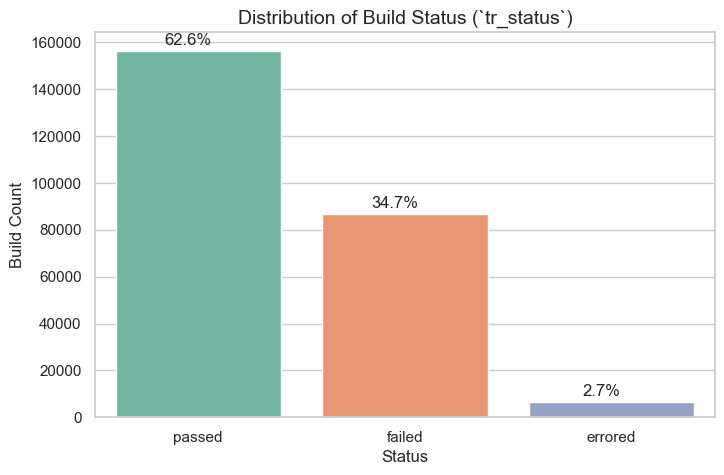

In [9]:
if 'tr_status' in df.columns:
    plt.figure(figsize=(8, 5))
    ax = sns.countplot(data=df, x='tr_status', order=df['tr_status'].value_counts().index, palette="Set2")
    
    # Add percentage labels
    total = len(df['tr_status'].dropna())
    for p in ax.patches:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        x = p.get_x() + p.get_width() / 2 - 0.05
        y = p.get_y() + p.get_height() + (total*0.01)
        ax.annotate(percentage, (x, y), ha='center')
        
    plt.title("Distribution of Build Status (`tr_status`)", fontsize=14)
    plt.ylabel("Build Count")
    plt.xlabel("Status")
    plt.show()
else:
    print("'tr_status' not found in dataset.")

## 4. Distribution of Key Numerical Features
Let's see the span of build duration. Note that extreme values (e.g. 0 duration, or extremely long times) could denote bugs and need filtering.

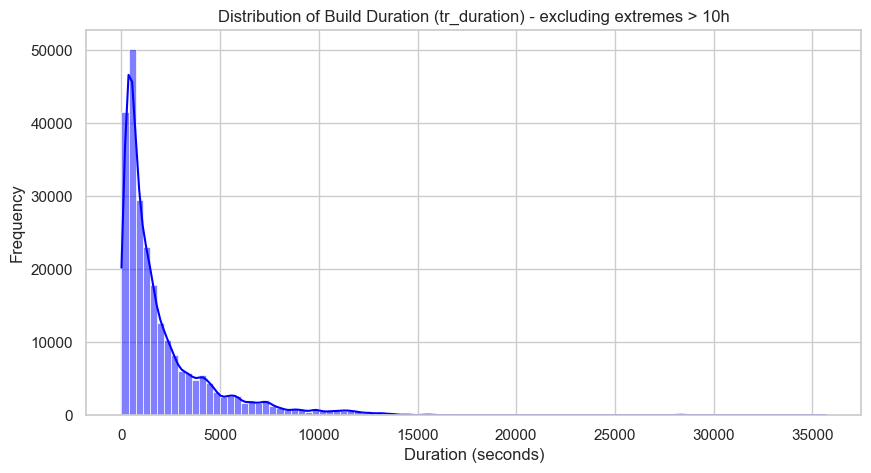

In [10]:
if 'tr_duration' in df.columns:
    # Remove obvious outliers for visualization (e.g. over 10 hours)
    valid_durations = df[df['tr_duration'] < 36000]['tr_duration']
    
    plt.figure(figsize=(10, 5))
    sns.histplot(valid_durations, bins=100, kde=True, color="blue")
    plt.title("Distribution of Build Duration (tr_duration) - excluding extremes > 10h")
    plt.xlabel("Duration (seconds)")
    plt.ylabel("Frequency")
    plt.show()

## 5. Feature Correlation
A correlation heatmap highlights features that are redundant (e.g. `gh_test_lines_added` vs `gh_test_lines_deleted`). Identifying these lets us prune the dataset prior to machine learning explicitly mapping out collinearity.

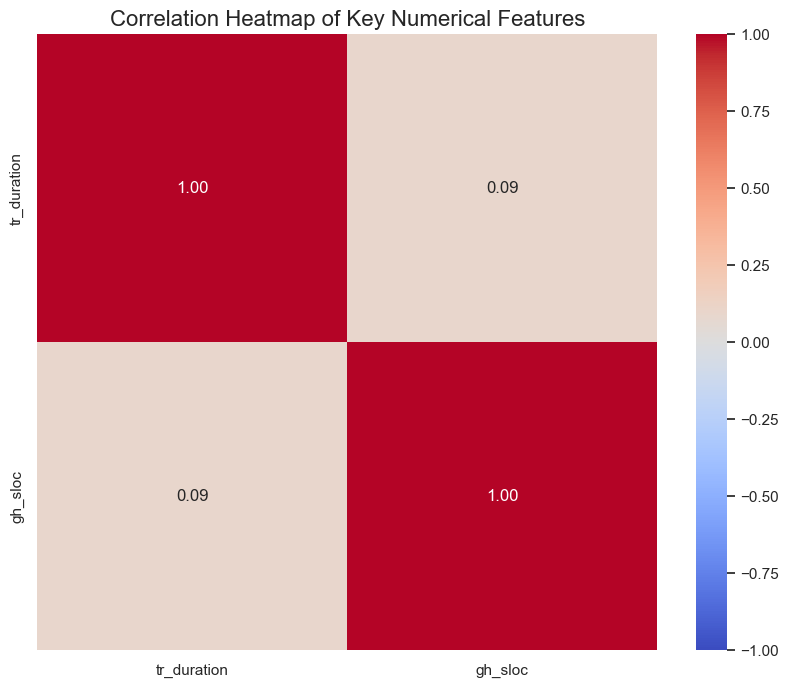

In [11]:
# Select only numerical features for correlation matrix
numeric_df = df.select_dtypes(include=[np.number])

# Check for some known key features based on proposal
key_features = [
    'tr_duration', 'gh_src_churn', 'gh_test_churn', 'gh_sloc',
    'gh_files_added', 'gh_files_deleted', 'gh_files_modified'
]
# Filter to existing columns only
available_keys = [f for f in key_features if f in numeric_df.columns]

if available_keys:
    corr_matrix = numeric_df[available_keys].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
    plt.title("Correlation Heatmap of Key Numerical Features", fontsize=16)
    plt.show()

## 6. Recommendations for Data Engineering pipeline
Based on the full EDA observation, for our modeling pipeline:
1. Drop columns with >90% missing values (e.g. `gh_timestamp...`, `gh_commits_in_push`) completely.
2. Fill NaN in test logs (`tr_log_...`) with `0`.
3. Consolidate `tr_status`: Map `failed` and `errored` into `1`, and `passed` into `0`.
4. Filter out any rows with missing or unrealistic `tr_duration` (< 0 or > 24h).
5. Generate `total_churn` feature and parse `gh_pushed_at` into `hour` and `day_of_week`.